## CCA performance test
---

In this interactive tutorial we demonstrate the usage of simulation based inference




In [ ]:
import os
# Expose all CPU cores as separate JAX devices before importing JAX
os.environ["XLA_FLAGS"] = f"--xla_force_host_platform_device_count={os.cpu_count()}"

import numpy as np
from getdist import plots, MCSamples
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.linalg import eigh
from scipy import stats as st
from sbi.inference import NLE, NPE
from sbi.utils import BoxUniform
import torch
from tqdm import tqdm
from nautilus import Sampler as NautilusSampler, Prior as NautilusPrior
import functools

import jax
import jax_cosmo as jc
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)

print(f"JAX devices: {jax.device_count()} (CPU cores exposed)")

## Notebook outline

First, let's define some helper functions

## Plotting function

In [30]:
def triangle_plot(
    mc_samples,
    truth=None,
    params_to_plot=None,
    savefig=False,
    filename=None,
):
    # Triangle plot
    plt.close()
    with mpl.rc_context():
        # g = plots.getSubplotPlotter(width_inch=12)
        g = plots.getSubplotPlotter()
        g.settings.figure_legend_frame = False
        g.settings.alpha_filled_add = 0.6
        g.settings.axes_fontsize = 18
        g.settings.legend_fontsize = 18
        g.settings.lab_fontsize = 18
        if params_to_plot:
            g.triangle_plot(
                mc_samples, params=params_to_plot, filled_compare=True, normalized=True
            )
        else:
            g.triangle_plot(mc_samples, filled_compare=True, normalized=True)

        if truth is not None:
            g.add_param_markers(truth, color="black", ls="--")

        plt.subplots_adjust(hspace=0, wspace=0)

        if savefig:
            plt.savefig(filename, bbox_inches="tight")
        plt.show()
        
def plot_spectra(spectra):
    pass
    

## For a cosmic shear simulator, we need to first define some redshift bins

Here we are making use of smail distributions of widening width, defined as

$$
n(z)=z_a \exp{(z/z_0)^b}
$$

This defines for us the number density of "objects", in our case galaxies, in a given tomographic bin. 

We can think of each tomographic bin as a "shell" of observations going further away from us that we have banded together. 

We have split our mock galaxy survey into 5 tomographic bins.

In [31]:
nz1 = jc.redshift.smail_nz(1., 2.,  0.5)
nz2 = jc.redshift.systematic_shift(jc.redshift.smail_nz(1., 2., 0.6), 0.5)
nz3 = jc.redshift.systematic_shift(jc.redshift.smail_nz(1., 2., 0.8), 1.2)
nz4 = jc.redshift.systematic_shift(jc.redshift.smail_nz(1., 2., 1.0), 1.8)
nz5 = jc.redshift.systematic_shift(jc.redshift.smail_nz(1., 2., 1.2), 2.4)

nzs = [nz1, nz2, nz3, nz4, nz5]

## Let's also plot it to convince ourselves things are looking right

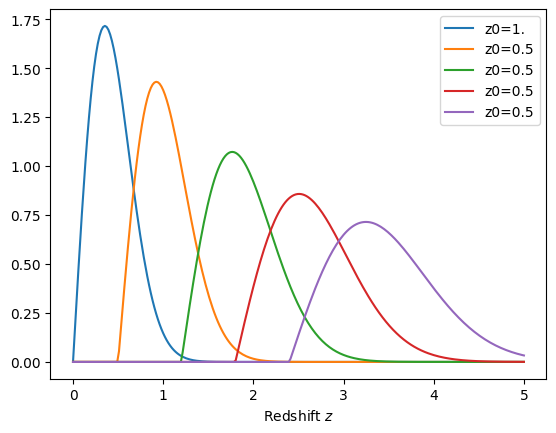

In [32]:
# And let's plot it
z = np.linspace(0,5,256)

# Redshift distributions are callable, and they return the normalized distribution
plt.plot(z, nz1(z), label='z0=1.')
plt.plot(z, nz2(z), label='z0=0.5')
plt.plot(z, nz3(z), label='z0=0.5')
plt.plot(z, nz4(z), label='z0=0.5')
plt.plot(z, nz5(z), label='z0=0.5')
plt.legend()
plt.xlabel('Redshift $z$');

## We also need to define some probes to describe what exactly we are observing

In [33]:
probes = [jc.probes.WeakLensing(nzs, sigma_e=0.26),]

## Lastly we also need to define the ell range that we want our power spectrum to go up to

In [34]:
ell = np.logspace(np.log10(2), np.log10(1000), 100)

## Let's run a cosmological simulator to calculate a lensing power spectrum with our parameter setup

In [35]:
cosmo_data = jc.Planck15()

In [36]:
cls = jc.angular_cl.angular_cl(cosmo_data, ell, probes)
noise_cls = jc.angular_cl.noise_cl(ell, probes)
cov = jc.angular_cl.gaussian_cl_covariance(ell, probes, cls, noise_cls, sparse=False)
cls_noise = jax.random.multivariate_normal(mean=jnp.concatenate(cls), cov=cov, key=jax.random.PRNGKey(42))

## Let's plot this all to see what our data vector looks like

So here we are plotting the auto power spectrum and cross power spectrum across all of the tomographic bins for weak lensing

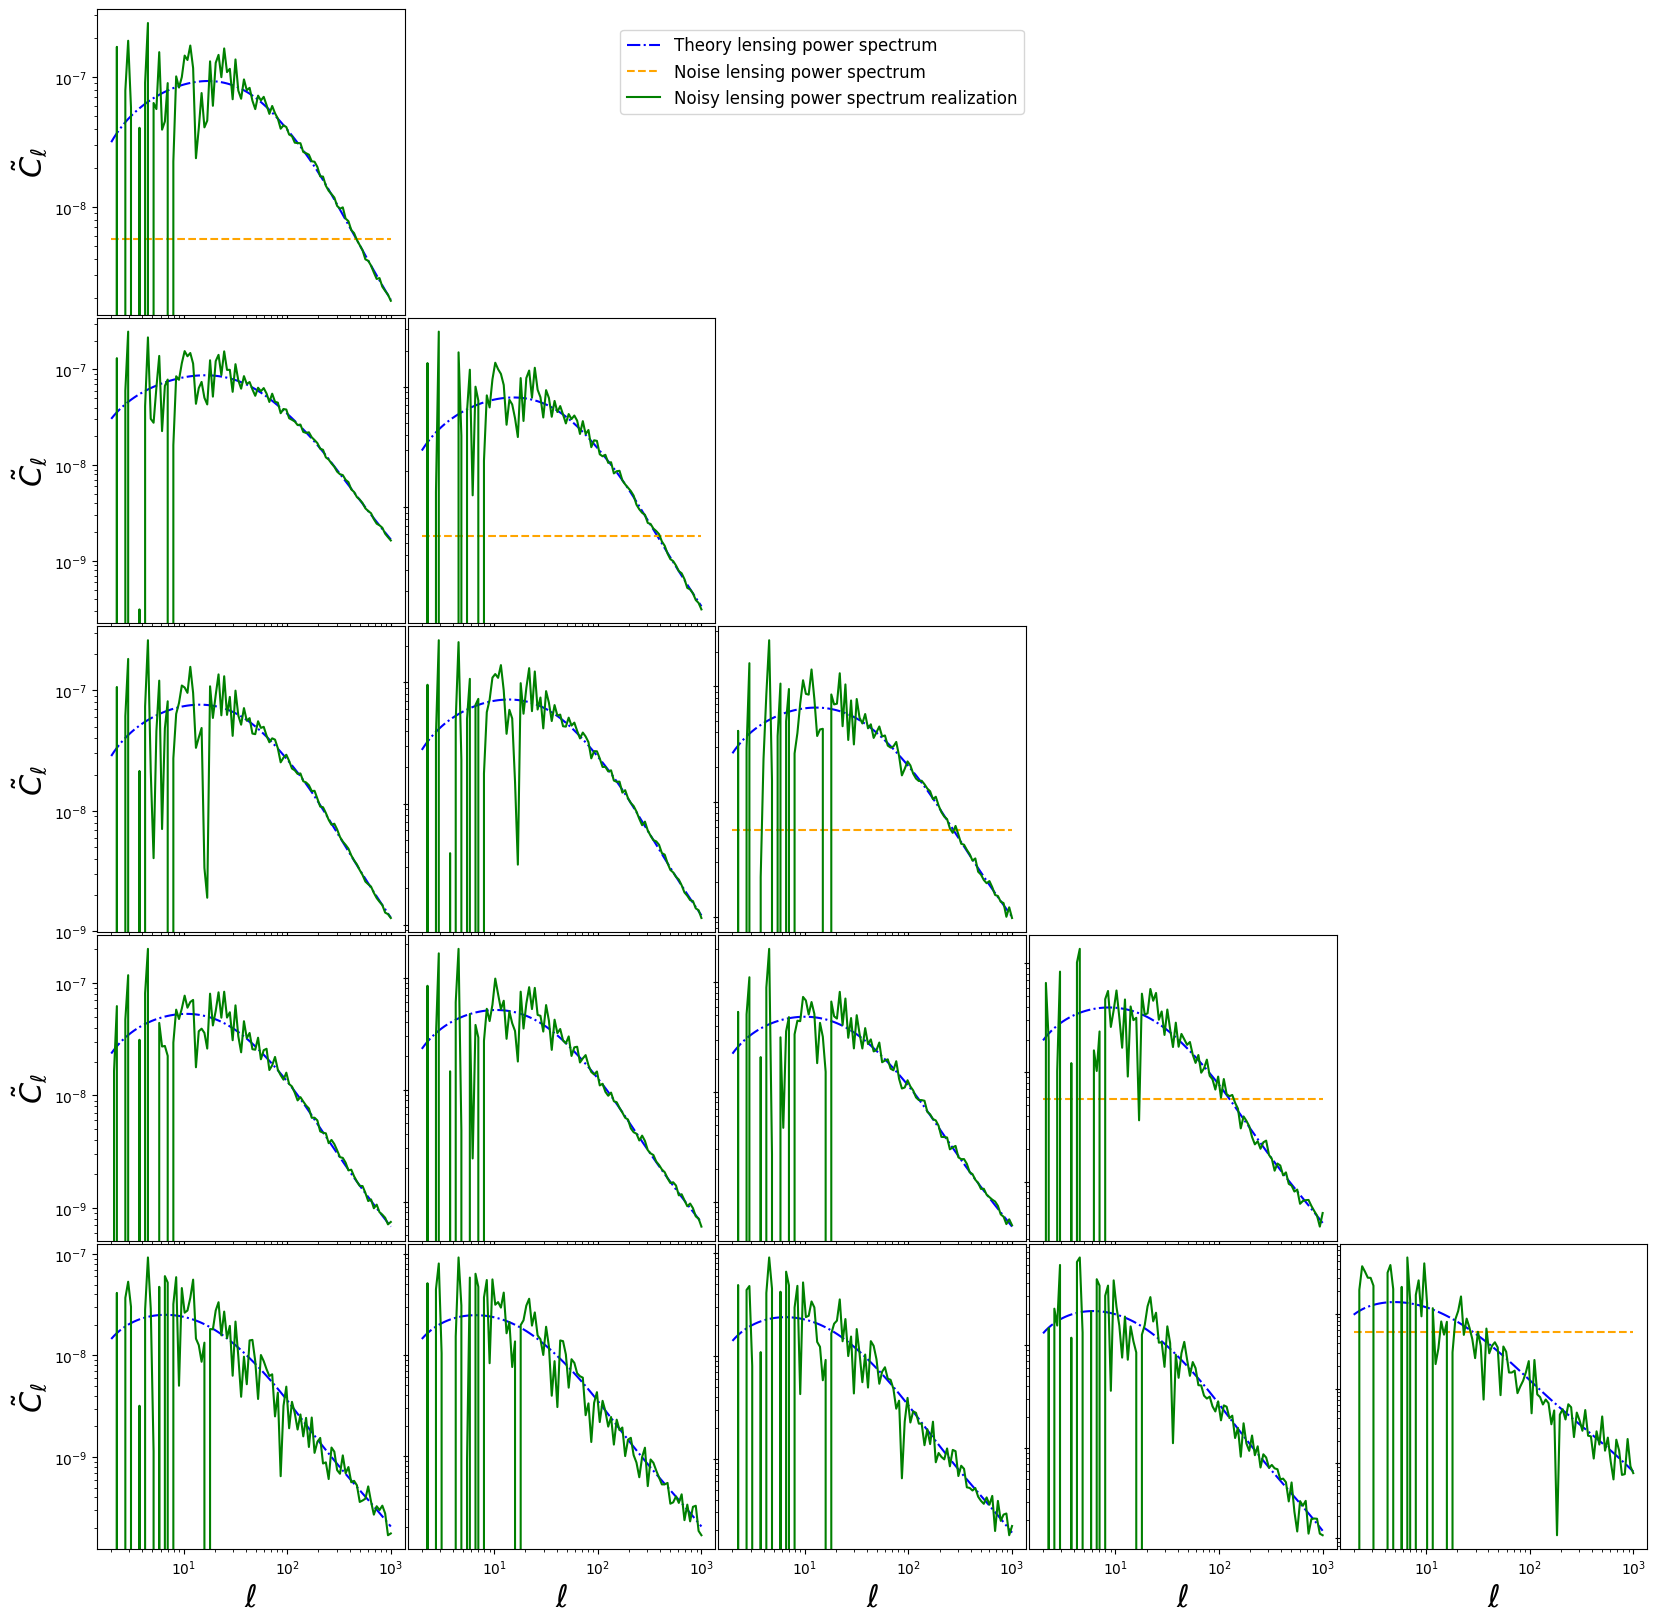

In [37]:
counter=0
fig, axs = plt.subplots(len(nzs), len(nzs), figsize=(20, 20))

cls_plot = cls[::-1]
noise_cls_plot = noise_cls[::-1]
cls_noise_plot = cls_noise.reshape(cls.shape)[::-1]

for i in range(0, len(nzs)):
    for j in range(0, len(nzs)):
        if i<j:
            axs[i, j].axis('off')
        else:
            axs[i, j].plot(ell, cls_plot[counter], c='blue', ls = '-.', label='Theory lensing power spectrum')
            axs[i, j].plot(ell, noise_cls_plot[counter], c='orange', ls = '--', label='Noise lensing power spectrum')
            axs[i, j].plot(ell, cls_noise_plot[counter], c='green', ls = '-', label='Noisy lensing power spectrum realization')
            axs[i, j].set_xscale('log')
            axs[i, j].set_yscale('log')

            if i == len(nzs) - 1:
                axs[i, j].set_xlabel(r'$\ell$', fontsize=22)
            else:
                plt.setp(axs[i, j].get_xticklabels(), visible=False)
            
            if j == 0:
                axs[i, j].set_ylabel(r'$\tilde{C}_{\ell}$', fontsize=22)
            else:
                plt.setp(axs[i, j].get_yticklabels(), visible=False)

            counter += 1

plt.legend(bbox_to_anchor=(-1, 5), loc='upper right', fontsize=12)
plt.subplots_adjust(wspace=0.01, hspace=0.01)
plt.show()

## Let's turn this into jax vmappable simulator for efficiency

In [38]:
@jax.jit
def simulator(theta, key=jax.random.PRNGKey(42)):
    def single_sim(params, rng_key):
        cosmo = jc.Cosmology(
            sigma8=params[0],
            Omega_c=params[1],
            Omega_b=params[2],
            h=params[3],
            n_s=params[4],
            Omega_k=0.0,
            w0=-1.0,
            wa=0.0,
        )
        
        cls = jc.angular_cl.angular_cl(cosmo, ell, probes)
        cov = jc.angular_cl.gaussian_cl_covariance(ell, probes, cls, noise_cls, sparse=False)
        
        # Use JAX random generation instead of numpy
        return jax.random.multivariate_normal(rng_key, mean=jnp.concatenate(cls), cov=cov)

    # Split keys so each simulation gets a unique random seed
    keys = jax.random.split(key, theta.shape[0])
    
    # vmap the single simulation function over parameters and keys
    return jax.vmap(single_sim)(theta, keys)

In [39]:
def chunked_simulator(theta, chunk_size=100, key=jax.random.PRNGKey(42)):
    n_samples = theta.shape[0]
    n_chunks = int(np.ceil(n_samples / chunk_size))
    
    # Split the main key so each chunk gets a unique random state
    chunk_keys = jax.random.split(key, n_chunks)
    
    results = []
    for i in tqdm(range(n_chunks)):
        start = i * chunk_size
        end = min((i + 1) * chunk_size, n_samples)
        
        # Run the JIT-compiled simulator on the current batch
        batch_res = simulator(theta[start:end], key=chunk_keys[i])
        results.append(batch_res)
        
    return jnp.vstack(results)

## Set priors

Setting some flat priors for simplicity's sake


In [40]:
params = ['sigma_8', 'Omega_c', 'Omega_b', 'h', 'n_s']

lower = torch.tensor([0.5, 0.1, 0.04, 0.64, 0.84])
upper = torch.tensor([1.2, 0.5, 0.06, 0.82, 1.10])

prior = BoxUniform(low=lower, high=upper)

## Let's use the same simulator to generate some simulated data with Gaussian nose

In [ ]:
sim_samples_compression = prior.sample((10000,)).numpy()
simulated_data_compression = chunked_simulator(sim_samples_compression, chunk_size=10)

100%|██████████| 200/200 [02:17<00:00,  1.45it/s]


## Let's setup a compression method with CCA

Given the paired parameters and data,
$$
\begin{align}
\theta\in{\rm I\!R}^N,\;\;&\;\; X\in{\rm I\!R}^M \\
\end{align}
$$
we apply projection to both spaces.
$$
\begin{align}
\^{\theta}=U_\theta\theta\;,&\;\;\;\;U_\theta= \begin{pmatrix} w_1 & w_2 & \cdots & w_R \end{pmatrix}^T\\
\^{X}=U_XX\;,&\;\;\;\;U_X= \begin{pmatrix} v_1 & v_2 & \cdots & v_R \end{pmatrix}^T
\end{align}
$$
The vectors that form the compression matrix are solved via maximising the correlation in the projected space,
$$
w,\,v = \underset{w, v}{\operatorname{argmax}} \frac{w^{\top} \Sigma_{\theta X} v}{\sqrt{w^{\top} \Sigma_{\theta} w} \sqrt{v^{\top} \Sigma_{X} v}}
$$
where $\Sigma_{\theta X}$ is the cross covariance.
<br><br>Since we are seeking to compress the data vector $X$, we only need to find $v_1,...,v_R$. 

It would turn out that $R=min(N,M)$ due to the nature of the eigenvalue problem being solved when maximising the correlation.
$$
\Sigma_X^{-1}\Sigma_{X\theta}\Sigma_\theta^{-1}\Sigma_{\theta X} v = \lambda v
$$

In [42]:
n_params = sim_samples_compression.shape[1]

cca_cov = np.cov(sim_samples_compression.T, simulated_data_compression.T)
cp = cca_cov[:n_params,:n_params]
cd = cca_cov[n_params:,n_params:]
cpd = cca_cov[:n_params,n_params:]

# This 'cl' can be understood as the projection of 'cp' to data vector space
cl = cpd.T@np.linalg.inv(cp)@cpd

# As seen in the paper, this generalized eigenvalue problem is equivalent to CCA
# but is more numerically stable as 'cd' and 'cd-cl' are both invertible.
# This problem is motivated as mutual information maximization under Gaussian linear model assumptions
evals, evecs = eigh(cd, cd - cl)

# In the context of the CCA, only min( dim(param), dim(data vector)) components are real and the rest are noise. 
evals = evals[::-1][:n_params]
evecs = evecs[:,::-1][:,:n_params]

## Now let's make a mock data vector with our simulator and compress is

In [43]:
truth = [cosmo_data.sigma8, cosmo_data.Omega_c, cosmo_data.Omega_b, cosmo_data.h, cosmo_data.n_s]

In [44]:
mock_theta = torch.tensor([truth], dtype=torch.float32)
mock_obs = chunked_simulator(mock_theta.numpy(), chunk_size=1)[0]
compressed_obs = torch.as_tensor(np.asarray(mock_obs@evecs).copy(), dtype=torch.float32)

100%|██████████| 1/1 [00:08<00:00,  8.57s/it]


## Let's try to do an explicit mcmc run with this with a Gaussian likelihood

First work out the compressed covariance

In [45]:
compressed_cov = np.asarray(evecs.T @ np.asarray(cov) @ evecs)
compressed_cov_inv = np.linalg.inv(compressed_cov)

print("Compressed covariance shape:", compressed_cov.shape)
print("Compressed standard deviations:", np.sqrt(np.diag(compressed_cov)))

Compressed covariance shape: (5, 5)
Compressed standard deviations: [3.85653342 3.48753163 3.4435207  3.79651562 3.83281091]


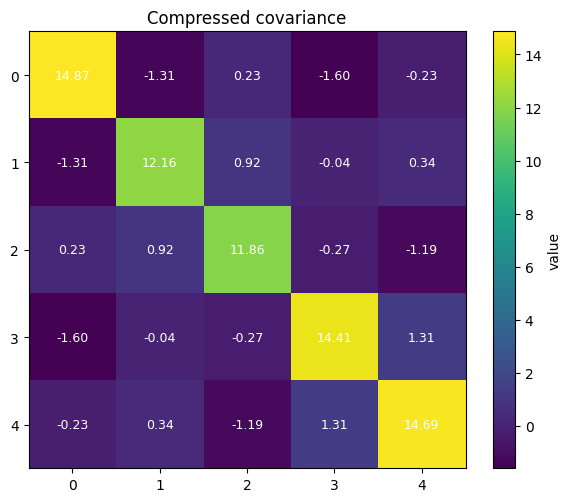

In [46]:
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(compressed_cov, cmap="viridis")

# Annotate each cell with its value
for i in range(compressed_cov.shape[0]):
    for j in range(compressed_cov.shape[1]):
        val = compressed_cov[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", color="white", fontsize=9)

ax.set_xticks(range(compressed_cov.shape[1]))
ax.set_yticks(range(compressed_cov.shape[0]))
ax.set_title("Compressed covariance")
fig.colorbar(im, ax=ax, label="value")
plt.tight_layout()
plt.show()

Setup the Nautilus sampler

In [ ]:
# Pre-convert static arrays to JAX arrays once
evecs_jax              = jnp.asarray(evecs)
compressed_obs_jax     = jnp.asarray(compressed_obs.numpy())
compressed_cov_inv_jax = jnp.asarray(compressed_cov_inv)

# Full covariance inverse — computed once to avoid repeated inversion
cov_inv     = np.linalg.inv(np.asarray(cov))
cov_inv_jax = jnp.asarray(cov_inv)
mock_obs_jax = jnp.asarray(np.asarray(mock_obs))

n_devices = jax.device_count()
print(f"JAX devices: {n_devices}")


def _make_nautilus_prior():
    """Build a Nautilus Prior matching the BoxUniform bounds."""
    p = NautilusPrior()
    for name, lo, hi in zip(params, lower.numpy(), upper.numpy()):
        p.add_parameter(name, dist=st.uniform(loc=lo, scale=float(hi - lo)))
    return p


def run_nautilus(compress=True, n_live=2000, n_networks=4, verbose=True):
    """
    Run Nautilus nested sampler with a Gaussian likelihood.

    Parameters
    ----------
    compress : bool
        If True,  applies the CCA projection to the theory cls and evaluates
        the likelihood in the compressed space (5×5 covariance).
        If False, uses the full uncompressed cls and full data covariance.
    n_live : int
        Number of live points. Higher gives more accurate evidence and
        smoother posteriors at the cost of more likelihood evaluations.
    n_networks : int
        Number of neural networks in the Nautilus importance-sampling ensemble.
    verbose : bool
        Print progress during sampling.

    Returns
    -------
    points  : np.ndarray, shape (n_samples, ndim)  — posterior samples
    log_w   : np.ndarray, shape (n_samples,)        — log importance weights
                (normalised so exp(log_w).sum() ≈ 1)
    log_l   : np.ndarray, shape (n_samples,)        — log-likelihoods
    """
    # ── per-sample log-likelihood ─────────────────────────────────────────────
    if compress:
        obs_jax_     = compressed_obs_jax
        cov_inv_jax_ = compressed_cov_inv_jax

        def _single_like(p):
            cosmo = jc.Cosmology(
                sigma8=p[0], Omega_c=p[1], Omega_b=p[2],
                h=p[3], n_s=p[4], Omega_k=0., w0=-1., wa=0.)
            cls_ = jc.angular_cl.angular_cl(cosmo, ell, probes)
            theory = jnp.concatenate(cls_) @ evecs_jax
            diff = obs_jax_ - theory
            return -0.5 * diff @ cov_inv_jax_ @ diff
    else:
        obs_jax_     = mock_obs_jax
        cov_inv_jax_ = cov_inv_jax

        def _single_like(p):
            cosmo = jc.Cosmology(
                sigma8=p[0], Omega_c=p[1], Omega_b=p[2],
                h=p[3], n_s=p[4], Omega_k=0., w0=-1., wa=0.)
            cls_ = jc.angular_cl.angular_cl(cosmo, ell, probes)
            theory = jnp.concatenate(cls_)
            diff = obs_jax_ - theory
            return -0.5 * diff @ cov_inv_jax_ @ diff

    # ── batched evaluators (pmap + vmap, or vmap-only fallback) ──────────────
    @functools.partial(jax.pmap, axis_name='devices')
    def _pmap_batch(theta_shard):
        return jax.vmap(_single_like)(theta_shard)

    _vmap_batch = jax.jit(jax.vmap(_single_like))

    def _eval_batch(theta_batch):
        """Evaluate log-likelihood for an arbitrarily-sized batch."""
        n = theta_batch.shape[0]
        if n_devices > 1:
            # Pad to a multiple of n_devices so pmap shards evenly
            n_padded = max(n_devices, int(np.ceil(n / n_devices)) * n_devices)
            theta_padded = (
                jnp.concatenate(
                    [theta_batch, jnp.tile(theta_batch[:1], (n_padded - n, 1))],
                    axis=0,
                ) if n_padded > n else theta_batch
            )
            sharded = theta_padded.reshape(n_devices, -1, theta_batch.shape[-1])
            return np.asarray(_pmap_batch(sharded).reshape(-1)[:n])
        else:
            return np.asarray(_vmap_batch(theta_batch))

    # ── Nautilus vectorized likelihood ────────────────────────────────────────
    # Nautilus passes a dict {param_name: array_of_values} when vectorized=True
    def log_likelihood(param_dict):
        theta = jnp.stack(
            [jnp.asarray(param_dict[name]) for name in params], axis=-1
        )  # shape (n_points, ndim)
        return _eval_batch(theta)

    # ── build sampler and run ─────────────────────────────────────────────────
    nautilus_prior = _make_nautilus_prior()
    label = "compressed" if compress else "uncompressed"
    print(f"Running Nautilus ({label}) | n_live={n_live}  n_networks={n_networks}  ndim={len(params)}")
    if n_devices > 1:
        print(f"Strategy: pmap ({n_devices} devices) + vmap")
    else:
        print("Strategy: vmap only (single device)")

    sampler = NautilusSampler(
        nautilus_prior,
        log_likelihood,
        n_live=n_live,
        n_networks=n_networks,
        vectorized=True,   # Nautilus passes batches; we handle parallelism via JAX
    )
    sampler.run(verbose=verbose)

    # posterior() returns (dict_of_arrays, log_w, log_l) when using named Prior
    points, log_w, log_l = sampler.posterior()
    if isinstance(points, dict):
        points = np.column_stack([points[name] for name in params])

    points = np.asarray(points)
    log_w  = np.asarray(log_w)
    log_l  = np.asarray(log_l)

    print(f"Posterior samples: {points.shape[0]}"    )
    return points, log_w, log_l

In [ ]:
nautilus_compressed_points, nautilus_compressed_log_w, nautilus_compressed_log_l = run_nautilus(compress=True, n_live=2000)

In [ ]:
nautilus_points, nautilus_log_w, nautilus_log_l = run_nautilus(compress=False, n_live=2000)

Strategy: pmap (24 devices) + vmap
Running emcee (uncompressed) | nwalkers=72  ndim=5  nsteps=800


100%|██████████| 800/800 [27:38<00:00,  2.07s/it]

Flattened samples shape: (57600, 5)
Flattened log-prob shape: (57600,)


## Now let's do some SBI with NLE
An overview of the NLE method is as follows:
1. Define prior $\pi(\theta)$
2. Introduce proposal likelihood $q_\phi(x|\theta)$ represented by a conditional normalising flow network.
3. Obtain training data $(x,\theta)$ using $\theta\sim \pi(\theta)$
4. Train $q_\phi(x|\theta)$ to approximate the true likelihood $p(x|\theta)$ with respect to the loss. $D_{KL}(\,p(x|\theta)\,||\,q_\phi(x|\theta)\,)$.
5. For sequential, repeat steps 3 and 4 but change the distribution we draw simulations from 

Here are some references:
1. Sequential neural likelihood: Fast likelihood-free inference with autoregressive flows (Papamarkaios, Sterratt & Murray 2019)
2. Fast likelihood-free cosmology with neural density estimators and active learning (Alsing, Feeney, Charnock, Wandelt 2019)
3. Flexible and efficient simulation-based inference for models of decision-making (Boelts, Lueckmann, Gao, Macke 2022)
4. KiDS-SBI: Simulation-based inference analysis of KiDS-1000 cosmic shear (von Wietersheim-Kramsta, Lin, Tessore, Joachimi, Loureiro, Reischke, Wright 2024)

In [50]:
num_sims = 1000
num_rounds = 5
nle_inference = NLE(prior)
nle_proposal = prior

In [51]:
for _ in range(num_rounds):
    theta = nle_proposal.sample((num_sims,))
    x = chunked_simulator(theta.detach().numpy(), chunk_size=10)
    compressed_x = np.asarray(x)@evecs # This is the step where we apply the compression from above to our simulated data
    compressed_x = torch.tensor(compressed_x, dtype=torch.float32)
    _ = nle_inference.append_simulations(theta, compressed_x).train()
    nle_posterior = nle_inference.build_posterior().set_default_x(compressed_obs)
    nle_proposal = nle_posterior

100%|██████████| 100/100 [00:59<00:00,  1.67it/s]


 Neural network successfully converged after 124 epochs.

/home/kiyam/cosmology/cca_test/.venv/lib/python3.12/site-packages/sbi/inference/posteriors/mcmc_posterior.py:126: UserWarning: The default value for thinning in MCMC sampling has been changed from 10 to 1. This might cause the results differ from the last benchmark.
  thin = _process_thin_default(thin)


Generating 20 MCMC inits via resample strategy:   0%|          | 0/20 [00:00<?, ?it/s]

Running vectorized MCMC with 20 chains:   0%|          | 0/6000 [00:00<?, ?it/s]

...

 Neural network successfully converged after 24 epochs.

Generating 20 MCMC inits via resample strategy:   0%|          | 0/20 [00:00<?, ?it/s]

Running vectorized MCMC with 20 chains:   0%|          | 0/6000 [00:00<?, ?it/s]

100%|██████████| 100/100 [00:59<00:00,  1.68it/s]


 Neural network successfully converged after 43 epochs.

## Get some posterior samples with emcee


In [52]:
nle_posterior_theta = nle_posterior.sample((20000,), x=compressed_obs, num_chains=100)

Generating 100 MCMC inits via resample strategy:   0%|          | 0/100 [00:00<?, ?it/s]

Running vectorized MCMC with 100 chains:   0%|          | 0/45000 [00:00<?, ?it/s]

## Let's also calculate the log probs for these samples

In [53]:
nle_posterior_samples = nle_posterior_theta.detach().numpy()
nle_posterior_log_probs = nle_posterior.potential(nle_posterior_theta.detach(), x=torch.tensor(compressed_obs, dtype=torch.float32)).numpy()

/tmp/ipykernel_570085/3446126637.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  nle_posterior_log_probs = nle_posterior.potential(nle_posterior_theta.detach(), x=torch.tensor(compressed_obs, dtype=torch.float32)).numpy()


## Plot!


In [54]:
param_labels = [r'\sigma_8', r'\Omega_c', r'\Omega_b', r'h', r'n_s']
truth = [cosmo_data.sigma8, cosmo_data.Omega_c, cosmo_data.Omega_b, cosmo_data.h, cosmo_data.n_s]
truth_marker = dict(zip(params, truth))

In [ ]:
nle_samples = MCSamples(
    samples=nle_posterior_samples,
    loglikes=nle_posterior_log_probs,
    names=params,
    labels=param_labels,
    label="NLE SBI",
    sampler="mcmc",
)

# Nautilus returns importance-weighted samples; pass weights to getdist
nautilus_weights = np.exp(nautilus_log_w - nautilus_log_w.max())
nautilus_weights /= nautilus_weights.sum()

nautilus_MC_samples = MCSamples(
    samples=nautilus_points,
    weights=nautilus_weights,
    loglikes=-nautilus_log_l,
    names=params,
    labels=param_labels,
    label="Nautilus",
)

In [ ]:
triangle_plot(
    [nle_samples, nautilus_MC_samples],
    truth=truth_marker)

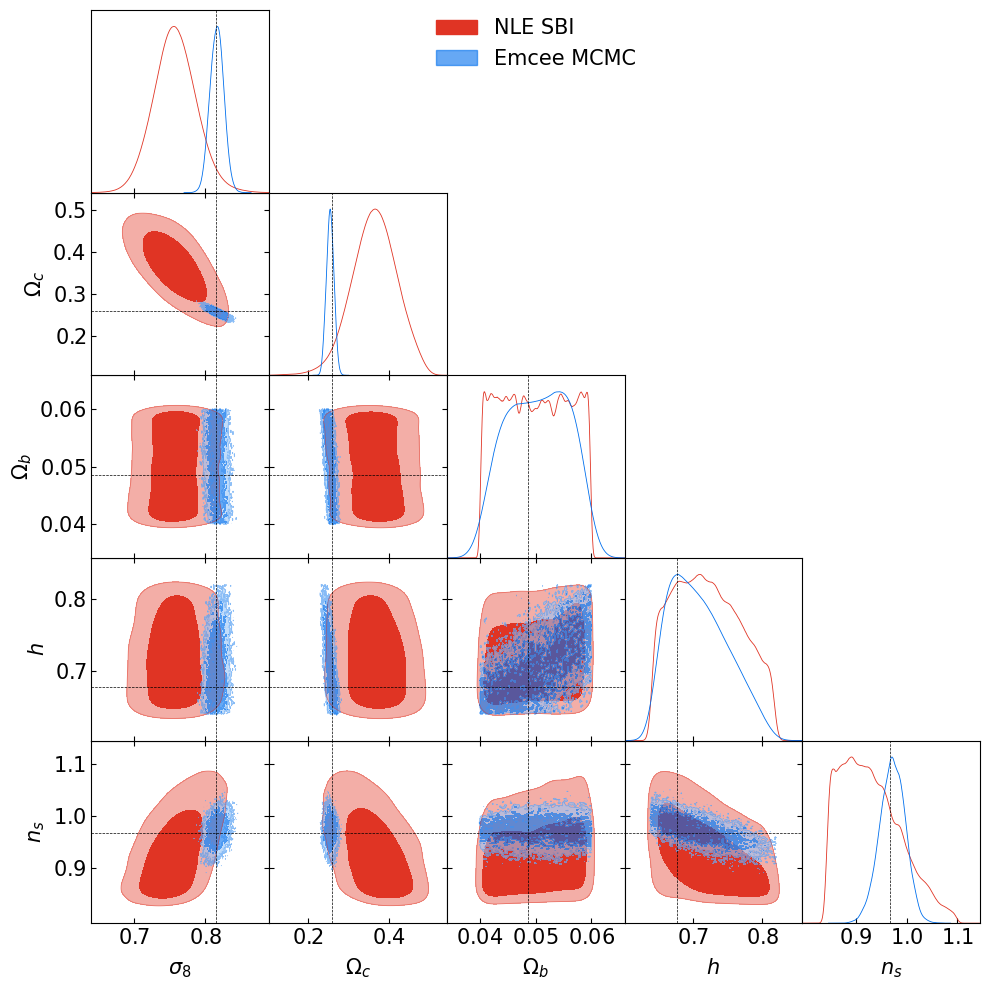

In [60]:
triangle_plot(
    [nle_samples, emcee_MC_samples],
    truth=truth_marker)